In [1]:
import torch.nn as nn
import torch
from torchvision import datasets, transforms
import torchvision

from torch.utils.data import DataLoader

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [3]:
config = {
    "patch_size": 4,          # 🔥 smaller patches = better learning
    "num_channle": 3,
    "img_size": 32,
    "batch_size": 64,

    "emmding_dim": 192,       # slightly stronger
    "num_patch": 64,          # 32/4 = 8 → 8x8 = 64 patches

    "dropout": 0.1,           # 🔥 important

    "Att_head": 8,
    "qkv_bias": True,
    "num_layer": 6,

    "num_classes": 10
}

In [5]:
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616))
])

train_dataset = datasets.CIFAR10(root="./data", train=True,
                                  download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root="./data", train=False,
                                 download=True, transform=test_transform)

100%|██████████| 170M/170M [07:37<00:00, 372kB/s]


In [6]:
train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=config["batch_size"], shuffle=True)

In [55]:
class Patch_Embeddings(nn.Module):
  def __init__(self,config):
    super().__init__()

    self.image_size = config["img_size"]
    self.patch_size = config["patch_size"]
    self.num_channle = config["num_channle"]
    self.embedding_dim = config["emmding_dim"]
    self.num_patches = (self.image_size // self.patch_size) ** 2

    self.patch = nn.Conv2d(self.num_channle, self.embedding_dim, kernel_size=self.patch_size, stride=self.patch_size )

  def forward(self,x):

    x = self.patch(x)
    x = x.flatten(2)
    x = x.transpose(1,2)
    return x



In [56]:
class Embeddings(nn.Module):
  def __init__(self,config):
    super().__init__()

    self.Patch_Embeddings = Patch_Embeddings(config)
    self.cls_token = nn.Parameter(torch.randn(1,1,config["emmding_dim"]))
    self.pos_embedding = nn.Parameter(torch.randn(1,1+config["num_patch"],config["emmding_dim"]))
    self.dropout = nn.Dropout(config["dropout"])

  def forward(self,x):

    x = self.Patch_Embeddings(x)
    batch_size,token,dim = x.size()
    cls_tokens = self.cls_token.expand(batch_size, -1, -1)
    x = torch.cat((cls_tokens, x), dim=1)
    x = x + self.pos_embedding
    x = self.dropout(x)
    return x




In [57]:
class Multi_Head_Attion(nn.Module):
     def __init__(self,config):
      super().__init__()

      self.dim_out = config["emmding_dim"]
      self.n_head = config["Att_head"]
      self.dim_head = self.dim_out // self.n_head
      self.W_query = nn.Linear(self.dim_out, self.dim_out, bias = config["qkv_bias"])
      self.W_key = nn.Linear(self.dim_out, self.dim_out, bias = config["qkv_bias"])
      self.W_values = nn.Linear(self.dim_out, self.dim_out, bias = config["qkv_bias"])
      self.dropout = nn.Dropout(config["dropout"])
      self.W_O = nn.Linear(self.dim_out, self.dim_out)

     def forward(self,x):
      batch_size, patch, d_in = x.shape
      query = self.W_query(x)
      key = self.W_key(x)
      values = self.W_values(x)

      query = query.view(batch_size, patch, self.n_head, self.dim_head)
      key = key.view(batch_size, patch, self.n_head, self.dim_head)
      values = values.view(batch_size, patch, self.n_head, self.dim_head)

      query = query.transpose(1,2)
      key = key.transpose(1,2)
      values = values.transpose(1,2)

      scores = torch.matmul(query, key.transpose(2,3))
      scores = scores / (self.dim_head ** 0.5)

      scores = torch.softmax(scores, dim=-1)
      scores = self.dropout(scores)

      out = torch.matmul(scores, values).transpose(1,2).contiguous().view(batch_size, patch, self.dim_out)
      out = self.W_O(out)
      return out





In [58]:
class LayerNorm(nn.Module):
  def __init__(self,config):
    super().__init__()
    self.eps = 1e-5
    self.dim_out = config["emmding_dim"]
    self.scale = nn.Parameter(torch.ones(config["emmding_dim"]))
    self.shift = nn.Parameter(torch.zeros(config["emmding_dim"]))

  def forward(self,x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps)
    return self.scale * norm_x + self.shift


In [59]:
class FeedForward(nn.Module):
  def __init__(self,config):
    super().__init__()

    self.layer = nn.Sequential(
        nn.Linear(config["emmding_dim"], 4 * config["emmding_dim"]),
        nn.GELU(),
        nn.Linear(4 * config["emmding_dim"], config["emmding_dim"])
    )
    self.dropout = nn.Dropout(config["dropout"])

  def forward(self,x):
    x = self.layer(x)
    x = self.dropout(x)
    return x



In [60]:
class Transformer_Block(nn.Module):
  def __init__(self,config):
    super().__init__()
    self.layer_norm1 = LayerNorm(config)
    self.layer_norm2 = LayerNorm(config)
    self.Multi_Head_Attion = Multi_Head_Attion(config)
    self.MLP = FeedForward(config)

  def forward(self,x):
    shortcut = x
    x = self.layer_norm1(x)
    x = self.Multi_Head_Attion(x)
    x = shortcut + x
    shortcut = x

    x = self.layer_norm2(x)
    x = self.MLP(x)
    x = shortcut + x

    return x

In [61]:
class Transformer_Encoder(nn.Module):
  def __init__(self,config):
    super().__init__()
    self.block = nn.ModuleList([Transformer_Block(config) for _ in range(config["num_layer"])])

    # self.block = nn.ModuleList([])
    # for _ in range(config["num_layer"]):
    #   self.block.append(Transformer_Block(config))

  def forward(self,x):
    for block in self.block:
      x = block(x)

    return x


In [62]:
class VisionTranformer(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.Embeddings = Embeddings(config)
    # self.Transformer_Block = nn.Sequential(*[Transformer_Block(config) for _ in range(config["num_layer"])])
    self.Transformer_Block = Transformer_Encoder(config)
    self.Norm = LayerNorm(config)
    self.Final_Layer = nn.Linear(config["emmding_dim"], config["num_classes"])

  def forward(self,x):
    x = self.Embeddings(x)
    x = self.Transformer_Block(x)
    x = self.Norm(x)
    x = x[:,0,:]
    logits = self.Final_Layer(x)
    return logits


In [63]:
model = VisionTranformer(config)
epochs = 25


In [64]:
import torch
from tqdm import tqdm

def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    device,
    lr=3e-4
):

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    model.to(device)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": []
    }

    for epoch in range(epochs):

        # -------------------
        # TRAIN
        # -------------------
        model.train()

        train_loss = 0
        correct = 0
        total = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

        for images, labels in loop:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(images)

            loss = criterion(logits, labels)

            loss.backward()

            # Important for transformers
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            train_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            loop.set_postfix(loss=loss.item())

        train_loss /= len(train_loader)
        train_acc = correct / total

        # -------------------
        # VALIDATION
        # -------------------
        model.eval()

        val_loss = 0
        correct = 0
        total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                logits = model(images)

                loss = criterion(logits, labels)

                val_loss += loss.item()

                preds = torch.argmax(logits, dim=1)

                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss /= len(val_loader)
        val_acc = correct / total

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["lr"].append(current_lr)

        print(
            f"\nEpoch {epoch+1}/{epochs}"
            f" | Train Loss: {train_loss:.4f}"
            f" | Train Acc: {train_acc:.4f}"
            f" | Val Loss: {val_loss:.4f}"
            f" | Val Acc: {val_acc:.4f}"
            f" | LR: {current_lr:.6f}"
        )

    return history

In [65]:
history = train_model(model=model, train_loader=train_loader, val_loader=test_loader, epochs=epochs, device=device)

Epoch 1/25: 100%|██████████| 782/782 [00:54<00:00, 14.25it/s, loss=1.84]



Epoch 1/25 | Train Loss: 1.7486 | Train Acc: 0.3525 | Val Loss: 1.4836 | Val Acc: 0.4673 | LR: 0.000300


Epoch 2/25: 100%|██████████| 782/782 [00:53<00:00, 14.49it/s, loss=1.5]



Epoch 2/25 | Train Loss: 1.4748 | Train Acc: 0.4649 | Val Loss: 1.3294 | Val Acc: 0.5192 | LR: 0.000300


Epoch 3/25: 100%|██████████| 782/782 [00:55<00:00, 14.11it/s, loss=1.48]


...


Epoch 23/25 | Train Loss: 0.6241 | Train Acc: 0.7775 | Val Loss: 0.7000 | Val Acc: 0.7596 | LR: 0.000300


Epoch 24/25: 100%|██████████| 782/782 [00:54<00:00, 14.46it/s, loss=0.936]



Epoch 24/25 | Train Loss: 0.6016 | Train Acc: 0.7849 | Val Loss: 0.6906 | Val Acc: 0.7617 | LR: 0.000300


Epoch 25/25: 100%|██████████| 782/782 [00:53<00:00, 14.50it/s, loss=0.432]



Epoch 25/25 | Train Loss: 0.5858 | Train Acc: 0.7916 | Val Loss: 0.6745 | Val Acc: 0.7708 | LR: 0.000300


In [66]:
%matplotlib inline
import torch
import matplotlib.pyplot as plt
import os

os.makedirs("assets", exist_ok=True)

classes = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

Saved → assets/training_curves.png


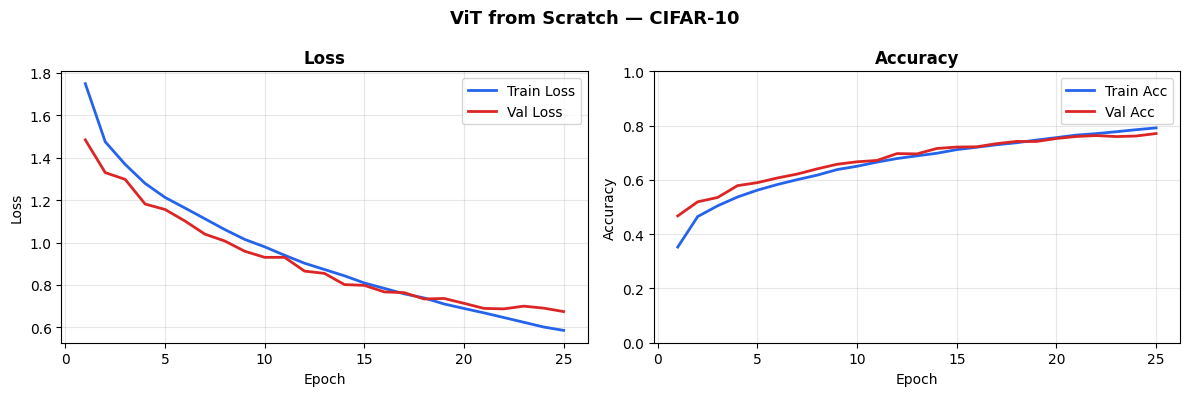

In [67]:
def plot_history(history, save=True):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)

    ax1.plot(epochs, history["train_loss"], label="Train Loss", color="#2563EB", linewidth=2)
    ax1.plot(epochs, history["val_loss"],   label="Val Loss",   color="#DC2626", linewidth=2)
    ax1.set_title("Loss", fontweight="bold")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history["train_acc"], label="Train Acc", color="#2563EB", linewidth=2)
    ax2.plot(epochs, history["val_acc"],   label="Val Acc",   color="#DC2626", linewidth=2)
    ax2.set_title("Accuracy", fontweight="bold")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_ylim(0, 1)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle("ViT from Scratch — CIFAR-10", fontweight="bold", fontsize=13)
    plt.tight_layout()

    if save:
        plt.savefig("assets/training_curves.png", dpi=150, bbox_inches="tight")
        print("Saved → assets/training_curves.png")

    plt.show()

plot_history(history)


Saved → assets/predictions.png


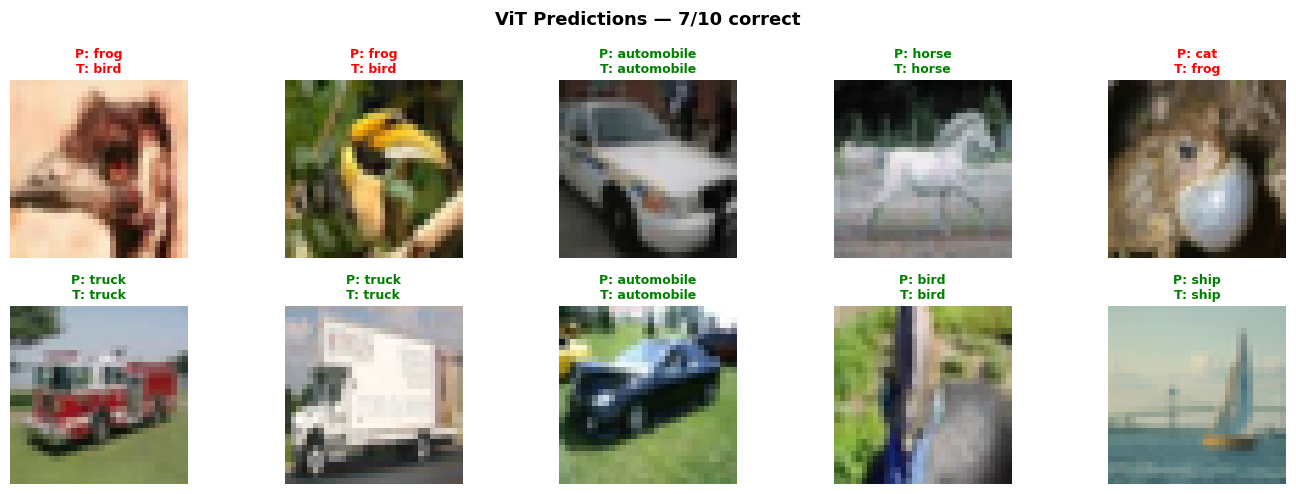

In [72]:
def predict_and_show(model, loader, device, num_images=10, save=True):
    mean = torch.tensor([0.4914, 0.4822, 0.4465])
    std  = torch.tensor([0.2470, 0.2435, 0.2616])

    model.eval()
    images, labels = next(iter(loader))
    images = images.to(device)

    with torch.no_grad():
        logits = model(images)
        preds  = torch.argmax(logits, dim=1).cpu()

    images = images.cpu()

    correct = (preds[:num_images] == labels[:num_images]).sum().item()

    plt.figure(figsize=(14, 5))
    plt.suptitle(
        f"ViT Predictions — {correct}/{num_images} correct",
        fontweight="bold", fontsize=13
    )

    for i in range(num_images):
        plt.subplot(2, 5, i + 1)

        img = images[i].permute(1, 2, 0)
        img = img * std + mean
        img = img.clamp(0, 1).numpy()

        plt.imshow(img)

        pred = preds[i].item()
        true = labels[i].item()

        color = "green" if pred == true else "red"
        plt.title(
            f"P: {classes[pred]}\nT: {classes[true]}",
            color=color, fontsize=9, fontweight="bold"
        )
        plt.axis("off")

    plt.tight_layout()

    if save:
        plt.savefig("assets/predictions.png", dpi=150, bbox_inches="tight")
        print("Saved → assets/predictions.png")

    plt.show()

predict_and_show(model, test_loader, device)

In [73]:
torch.save(model.state_dict(), "assets/vit_cifar10.pth")
print("Model saved!")

Model saved!
